In [1]:
# Get your own api key from kaggle to download the dataset from terminal
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [2]:
!kaggle datasets download ashwingupta3012/male-and-female-faces-dataset

Dataset URL: https://www.kaggle.com/datasets/ashwingupta3012/male-and-female-faces-dataset
License(s): CC0-1.0
 98% 1.59G/1.63G [00:15<00:00, 226MB/s]
100% 1.63G/1.63G [00:15<00:00, 111MB/s]


In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/male-and-female-faces-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models,layers
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D,BatchNormalization
from keras.models import Sequential
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/Male and Female face dataset',
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/Male and Female face dataset',
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(150, 150),
    batch_size=32
)


Found 5418 files belonging to 2 classes.
Using 3793 files for training.
Found 5418 files belonging to 2 classes.
Using 1625 files for validation.


In [6]:
def process(image,label):
  image = tf.cast(image/255., tf.float32)
  return image,label

In [7]:
train_ds = train_ds.map(process)
validation_ds = test_ds.map(process)

In [8]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),padding='valid',activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2, 2),strides=2,padding='valid'))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size=(3, 3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2),strides=2,padding='valid'))
model.add(Dropout(0.25))

model.add(Conv2D(128, kernel_size=(3, 3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2),strides=2,padding='valid'))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,836,673 (18.45 MB)

 Trainable params: 4,836,673 (18.45 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min'
)

In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [11]:
history = model.fit(train_ds,epochs=15,validation_data=validation_ds,callbacks=[early_stop])

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 93s 689ms/step - accuracy: 0.5497 - loss: 0.7008 - val_accuracy: 0.7538 - val_loss: 0.5337
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 95s 801ms/step - accuracy: 0.7507 - loss: 0.5145 - val_accuracy: 0.7932 - val_loss: 0.4344
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 142s 802ms/step - accuracy: 0.8257 - loss: 0.4028 - val_accuracy: 0.8511 - val_loss: 0.3203
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 83s 698ms/step - accuracy: 0.8746 - loss: 0.2925 - val_accuracy: 0.9028 - val_loss: 0.2598
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 96s 808ms/step - accuracy: 0.9094 - loss: 0.2297 - val_accuracy: 0.9354 - val_loss: 0.1806
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 78s 660ms/step - accuracy: 0.9334 - loss: 0.1670 - val_accuracy: 0.9415 - val_loss: 0.1503
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 642ms/step - accuracy: 0.9461 - loss: 0.1438 - val_accuracy: 0.9557 - val_loss: 0.1374
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 95s 802ms/step - accuracy: 0.9673 - loss: 

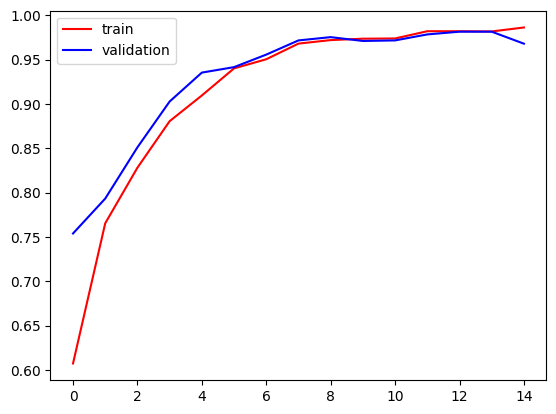

In [12]:
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

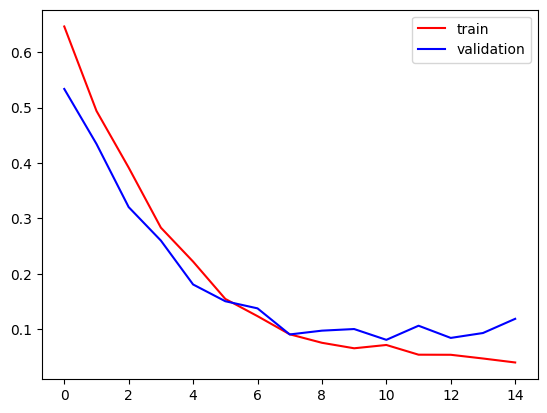

In [13]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [14]:
'''import tensorflow as tf
import numpy as np

img = tf.keras.utils.load_img("/content/download (1).jpg", target_size=(150,150))
img_array = tf.keras.utils.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]
label = "Female" if pred > 0.5 else "Male"

plt.imshow(tf.keras.utils.load_img('/content/download (1).jpg'))
plt.axis("off")
print(f"Prediction: {label} (confidence: {pred:.3f})")


FileNotFoundError: [Errno 2] No such file or directory: '/content/download (1).jpg'

In [15]:
model.save("gender_model.keras")